In [1]:
!pip install pandas pyarrow


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [5]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [7]:
import pandas as pd

In [8]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Ячейка 2: Q1 — Загружаем данные

In [11]:
print("=== Q1 ===")
df_train = pd.read_parquet('./data/yellow_tripdata_2026-03.parquet')
print("Количество колонок:", len(df_train.columns))

=== Q1 ===
Количество колонок: 20


In [12]:
# Ячейка 3: Q2 — Считаем длительность

In [13]:
print("\n=== Q2 ===")
df_train['duration'] = (df_train['tpep_dropoff_datetime'] - df_train['tpep_pickup_datetime']).dt.total_seconds() / 60
print("Стандартное отклонение длительности:", round(df_train['duration'].std(), 2))


=== Q2 ===
Стандартное отклонение длительности: 24.88


In [14]:
# Ячейка 4: Q3 — Убираем выбросы

In [15]:
print("\n=== Q3 ===")
original_len = len(df_train)
df_train = df_train[(df_train['duration'] >= 1) & (df_train['duration'] <= 60)]
print(f"Осталось записей: {len(df_train)/original_len:.2%}")


=== Q3 ===
Осталось записей: 95.49%


In [16]:
# Ячейка 5: Q4 — One-hot encoding

In [17]:
print("\n=== Q4 ===")
categorical = ['PULocationID', 'DOLocationID']
df_train[categorical] = df_train[categorical].astype(str)

dv = DictVectorizer()
train_dicts = df_train[categorical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)
print("Количество признаков после one-hot:", X_train.shape[1])


=== Q4 ===
Количество признаков после one-hot: 519


In [ ]:
# Ячейка 6: Q5 — Обучаем модель

In [19]:
print("\n=== Q5 ===")
y_train = df_train['duration'].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)

# ИСПРАВЛЕННАЯ СТРОКА ↓↓↓
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5

print("RMSE на тренировочных данных:", round(rmse_train, 2))


=== Q5 ===
RMSE на тренировочных данных: 8.91


In [20]:
# Ячейка 7: Q6 — Проверяем на апреле

In [23]:
print("\n=== Q6 ===")
df_val = pd.read_parquet('./data/yellow_tripdata_2026-04.parquet')

df_val['duration'] = (df_val['tpep_dropoff_datetime'] - df_val['tpep_pickup_datetime']).dt.total_seconds() / 60
df_val = df_val[(df_val['duration'] >= 1) & (df_val['duration'] <= 60)]

df_val[categorical] = df_val[categorical].astype(str)
val_dicts = df_val[categorical].to_dict(orient='records')
X_val = dv.transform(val_dicts)
y_val = df_val['duration'].values

y_pred_val = lr.predict(X_val)

rmse_val = mean_squared_error(y_val, y_pred_val) ** 0.5

print("RMSE на валидации (апрель):", round(rmse_val, 2))


=== Q6 ===
RMSE на валидации (апрель): 9.31


In [24]:
print("\n=== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МОДЕЛИ ===")


=== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МОДЕЛИ ===


In [27]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 60.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 63.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 68.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [28]:
print("\n=== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МОДЕЛИ ===")


=== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МОДЕЛИ ===


In [29]:
import matplotlib.pyplot as plt

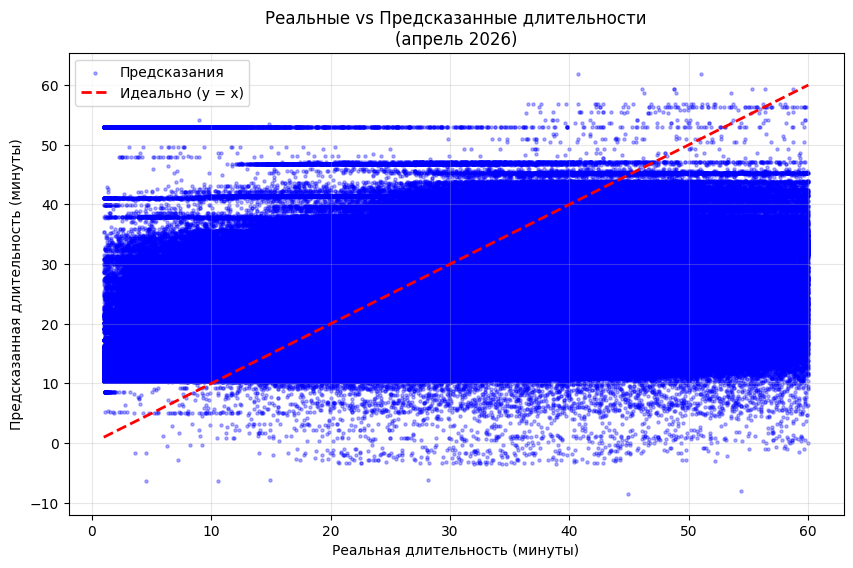

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred_val, alpha=0.3, s=5, color='blue', label='Предсказания')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Идеально (y = x)')
plt.xlabel('Реальная длительность (минуты)')
plt.ylabel('Предсказанная длительность (минуты)')
plt.title('Реальные vs Предсказанные длительности\n(апрель 2026)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

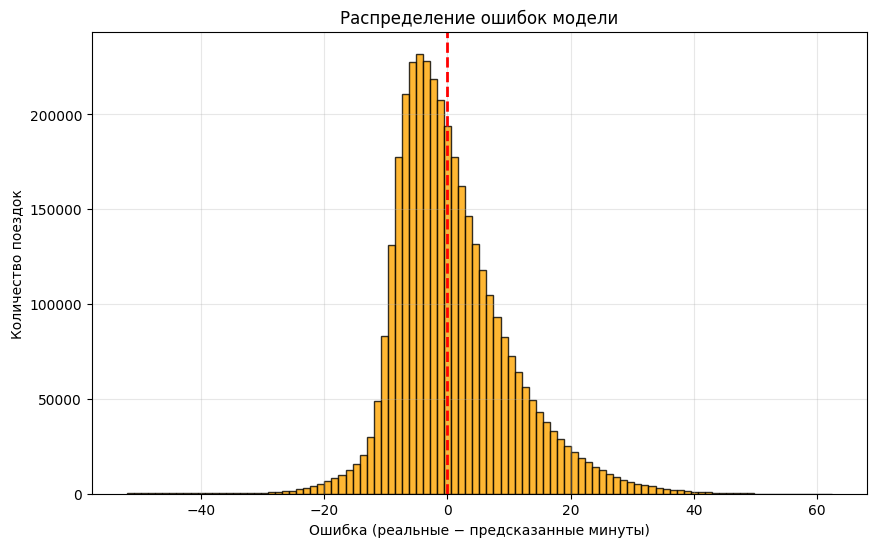

In [31]:
# 2. Распределение ошибок
residuals = y_val - y_pred_val
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=100, color='orange', edgecolor='black', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Ошибка (реальные − предсказанные минуты)')
plt.ylabel('Количество поездок')
plt.title('Распределение ошибок модели')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 3. Статистика
print(f"Средняя ошибка: {residuals.mean():.2f} минут")
print(f"Средняя абсолютная ошибка: {abs(residuals).mean():.2f} минут")
print(f"RMSE: {rmse_val:.2f} минут")